# 09 — Selección Balanceada del Set de Validación con Humanos

**Proyecto:** Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad  
**Autor:** Jesús Goenaga Peña  
**Fase:** 3 del pipeline de validación — Selección del set final

---

## ¿Qué hace este notebook?

Toma el archivo `pairs_ground_truth.csv` (200 imágenes con pares A/B definidos) y selecciona el subconjunto final de **200 imágenes balanceadas** para la validación con participantes humanos, garantizando:

1. **Exactamente 25 imágenes por celda factorial** (8 celdas × 25 = 200).
2. **Balance de ground truth dentro de cada celda**: aproximadamente 12-13 `mas_cercano` y 12-13 `mas_lejano` por celda.
3. **Orden de presentación aleatorizado** para evitar efectos de orden en los participantes.
4. **Archivo final listo para la interfaz experimental** del Notebook 11.

## Resultado

Archivo `validation_set_final.csv` — el insumo directo de la interfaz experimental.

---

## Celda 1 — Montar Drive y verificar rutas

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR    = '/content/drive/MyDrive/cognitive-depth-model'
SPLITS_DIR  = os.path.join(BASE_DIR, 'data', 'splits')
PAIRS_DIR   = os.path.join(BASE_DIR, 'results', 'pairs')
VALID_DIR   = os.path.join(BASE_DIR, 'results', 'validation_set')
os.makedirs(VALID_DIR, exist_ok=True)

CSV_PAIRS   = os.path.join(SPLITS_DIR, 'pairs_ground_truth.csv')

print('Verificación de rutas:')
print('-' * 50)
for nombre, ruta in [
    ('CSV pares A/B (NB08)', CSV_PAIRS),
    ('Carpeta pairs',        PAIRS_DIR),
    ('Carpeta validation',   VALID_DIR),
]:
    existe = os.path.exists(ruta)
    print(f'  {"✓" if existe else "✗"}  {nombre}')

print()
print('Si todo está en verde, continúa con la Celda 2.')

Mounted at /content/drive
Verificación de rutas:
--------------------------------------------------
  ✓  CSV pares A/B (NB08)
  ✓  Carpeta pairs
  ✓  Carpeta validation

Si todo está en verde, continúa con la Celda 2.


## Celda 2 — Importar librerías y cargar datos

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

df = pd.read_csv(CSV_PAIRS)
# Solo imágenes procesadas correctamente
df = df[df['error'].isna() | (df['error'] == '')].copy()
df = df.reset_index(drop=True)

print(f'Imágenes disponibles: {len(df)}')
print()
print('Distribución actual por celda factorial:')
tabla = df.groupby(
    ['tipo_tarea', 'nivel_disparidad', 'presencia_distractores']
).size().reset_index(name='N_disponibles')
print(tabla.to_string(index=False))
print()
print('Ground truth global:')
print(df['ground_truth'].value_counts().to_string())

Imágenes disponibles: 200

Distribución actual por celda factorial:
                tipo_tarea nivel_disparidad presencia_distractores  N_disponibles
discriminacion_profundidad             alta       con_distractores             27
discriminacion_profundidad             alta       sin_distractores             23
discriminacion_profundidad             baja       con_distractores             23
discriminacion_profundidad             baja       sin_distractores             27
            ilusion_visual             alta       con_distractores             28
            ilusion_visual             alta       sin_distractores             22
            ilusion_visual             baja       con_distractores             22
            ilusion_visual             baja       sin_distractores             28

Ground truth global:
ground_truth
mas_cercano    100
mas_lejano     100


## Celda 3 — Selección de 25 imágenes por celda con ground truth balanceado

In [3]:
N_POR_CELDA = 25  # Ideal según diseño factorial

celdas = [
    ('discriminacion_profundidad', 'alta',  'con_distractores'),
    ('discriminacion_profundidad', 'alta',  'sin_distractores'),
    ('discriminacion_profundidad', 'baja',  'con_distractores'),
    ('discriminacion_profundidad', 'baja',  'sin_distractores'),
    ('ilusion_visual',             'alta',  'con_distractores'),
    ('ilusion_visual',             'alta',  'sin_distractores'),
    ('ilusion_visual',             'baja',  'con_distractores'),
    ('ilusion_visual',             'baja',  'sin_distractores'),
]

seleccionados = []
reporte = []

for tarea, disp, dist in celdas:
    mask = (
        (df['tipo_tarea']             == tarea) &
        (df['nivel_disparidad']       == disp)  &
        (df['presencia_distractores'] == dist)
    )
    sub = df[mask].copy()
    n_disponibles = len(sub)

    if n_disponibles == 0:
        print(f'⚠ SIN IMÁGENES: {tarea} | {disp} | {dist}')
        continue

    # Seleccionar N_POR_CELDA con ground truth lo más balanceado posible
    n_objetivo   = min(N_POR_CELDA, n_disponibles)
    n_cercano    = n_objetivo // 2
    n_lejano     = n_objetivo - n_cercano

    sub_cercano = sub[sub['ground_truth'] == 'mas_cercano']
    sub_lejano  = sub[sub['ground_truth'] == 'mas_lejano']

    # Si no hay suficientes de un tipo, completar con el otro
    n_c_real = min(n_cercano, len(sub_cercano))
    n_l_real = min(n_lejano,  len(sub_lejano))
    deficit  = n_objetivo - (n_c_real + n_l_real)

    sel_c = sub_cercano.sample(n=n_c_real,  random_state=SEED)
    sel_l = sub_lejano.sample(n=n_l_real,   random_state=SEED)

    # Cubrir déficit con el grupo que tenga más disponibles
    if deficit > 0:
        resto_c = sub_cercano.drop(sel_c.index)
        resto_l = sub_lejano.drop(sel_l.index)
        if len(resto_c) >= deficit:
            sel_c = pd.concat([sel_c, resto_c.sample(n=deficit, random_state=SEED)])
        elif len(resto_l) >= deficit:
            sel_l = pd.concat([sel_l, resto_l.sample(n=deficit, random_state=SEED)])

    celda_sel = pd.concat([sel_c, sel_l])
    seleccionados.append(celda_sel)

    reporte.append({
        'Tarea':         tarea,
        'Disparidad':    disp,
        'Distractores':  dist,
        'N_disponibles': n_disponibles,
        'N_selec':       len(celda_sel),
        'GT_cercano':    (celda_sel['ground_truth']=='mas_cercano').sum(),
        'GT_lejano':     (celda_sel['ground_truth']=='mas_lejano').sum(),
    })

df_final = pd.concat(seleccionados, ignore_index=True)

print('Reporte de selección por celda:')
print('=' * 75)
df_rep = pd.DataFrame(reporte)
print(df_rep.to_string(index=False))
print()
print(f'Total seleccionado: {len(df_final)} imágenes')
print(f'GT global → cercano: {(df_final["ground_truth"]=="mas_cercano").sum()} | lejano: {(df_final["ground_truth"]=="mas_lejano").sum()}')

Reporte de selección por celda:
                     Tarea Disparidad     Distractores  N_disponibles  N_selec  GT_cercano  GT_lejano
discriminacion_profundidad       alta con_distractores             27       25          12         13
discriminacion_profundidad       alta sin_distractores             23       23          10         13
discriminacion_profundidad       baja con_distractores             23       23          14          9
discriminacion_profundidad       baja sin_distractores             27       25           9         16
            ilusion_visual       alta con_distractores             28       25          16          9
            ilusion_visual       alta sin_distractores             22       22          10         12
            ilusion_visual       baja con_distractores             22       22          12         10
            ilusion_visual       baja sin_distractores             28       25          12         13

Total seleccionado: 190 imágenes
GT global → cerc

## Celda 4 — Aleatorizar orden de presentación

In [4]:
# Mezclar el orden de presentación
# Esto evita efectos de orden y agrupamiento por condición
df_final = df_final.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Asignar número de tarea (1-200) — es el orden en que se presentará a los participantes
df_final['numero_tarea'] = df_final.index + 1

print('Orden de presentación aleatorizado.')
print(f'Total tareas: {len(df_final)}')
print()
print('Primeras 10 tareas en el orden de presentación:')
cols_preview = ['numero_tarea', 'imagen_id', 'dataset',
                'nivel_disparidad', 'presencia_distractores', 'ground_truth']
print(df_final[cols_preview].head(10).to_string(index=False))
print()

# Verificar que no hay agrupamiento por condición en el orden
# (que no aparezcan todas las KITTI juntas, por ejemplo)
print('Distribución de datasets en las primeras 20 tareas:')
print(df_final.head(20)['dataset'].value_counts().to_string())
print()
print('Distribución de datasets en las últimas 20 tareas:')
print(df_final.tail(20)['dataset'].value_counts().to_string())

Orden de presentación aleatorizado.
Total tareas: 190

Primeras 10 tareas en el orden de presentación:
 numero_tarea                                                                                               imagen_id     dataset nivel_disparidad presencia_distractores ground_truth
            1 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0298 3D_Illusion             baja       sin_distractores  mas_cercano
            2 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0309 3D_Illusion             baja       sin_distractores   mas_lejano
            3 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0196 3D_Illusion             alta       con_distractores  mas_cercano
            4                                                                                               000007_10       KITTI             baja       con_distract

## Celda 5 — Visualización del balance final

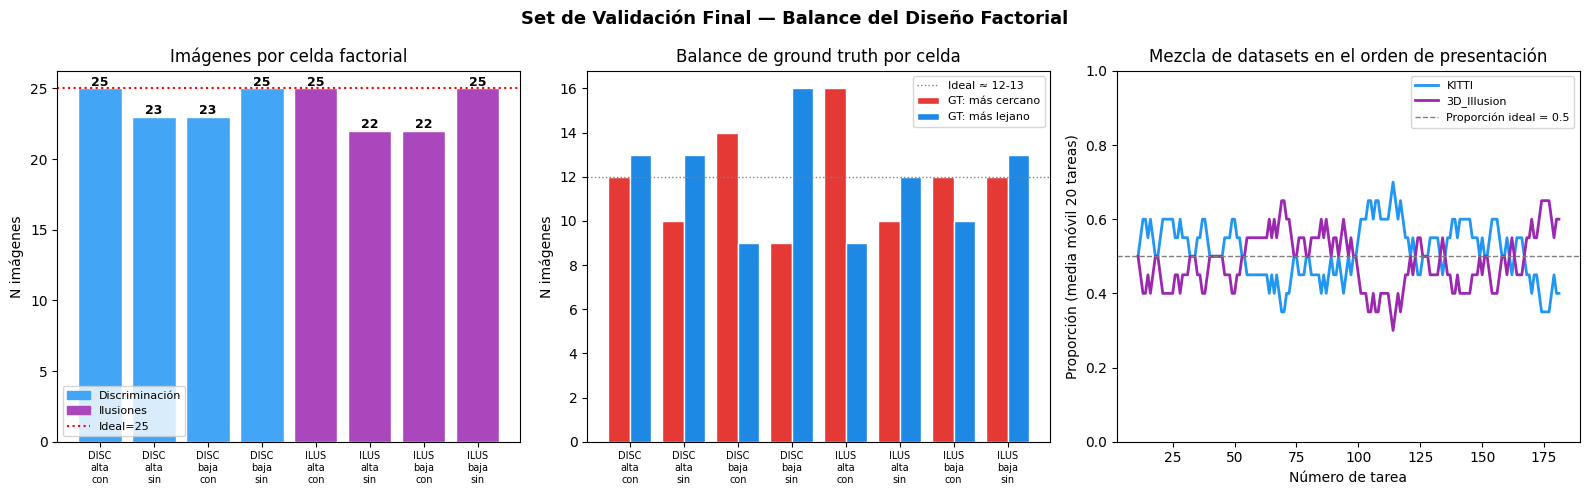

Figura guardada en: /content/drive/MyDrive/cognitive-depth-model/results/validation_set/balance_set_validacion.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Set de Validación Final — Balance del Diseño Factorial',
             fontsize=13, fontweight='bold')

# 1. N por celda factorial
ax = axes[0]
etiquetas = [
    f'{r["Tarea"][:4].upper()}\n{r["Disparidad"]}\n{r["Distractores"][:3]}'
    for _, r in df_rep.iterrows()
]
colores_tarea = ['#42A5F5' if 'disc' in r['Tarea'] else '#AB47BC'
                 for _, r in df_rep.iterrows()]
bars = ax.bar(range(len(df_rep)), df_rep['N_selec'],
              color=colores_tarea, edgecolor='white')
ax.set_xticks(range(len(df_rep)))
ax.set_xticklabels(etiquetas, fontsize=7)
ax.axhline(N_POR_CELDA, color='red', ls=':', lw=1.5, label=f'Ideal = {N_POR_CELDA}')
ax.set_ylabel('N imágenes')
ax.set_title('Imágenes por celda factorial')
ax.legend(fontsize=9)
for b, v in zip(bars, df_rep['N_selec']):
    ax.text(b.get_x()+b.get_width()/2, v+0.2, str(v),
            ha='center', fontsize=9, fontweight='bold')
azul  = mpatches.Patch(color='#42A5F5', label='Discriminación')
lila  = mpatches.Patch(color='#AB47BC', label='Ilusiones')
ax.legend(handles=[azul, lila, plt.Line2D([0],[0],color='red',ls=':',lw=1.5,label=f'Ideal={N_POR_CELDA}')],
          fontsize=8)

# 2. Balance de ground truth por celda
ax = axes[1]
x   = range(len(df_rep))
w   = 0.4
b1  = ax.bar([i-w/2 for i in x], df_rep['GT_cercano'], width=w,
              color='#E53935', label='GT: más cercano', edgecolor='white')
b2  = ax.bar([i+w/2 for i in x], df_rep['GT_lejano'],  width=w,
              color='#1E88E5', label='GT: más lejano',  edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas, fontsize=7)
ax.axhline(N_POR_CELDA//2, color='gray', ls=':', lw=1, label='Ideal ≈ 12-13')
ax.set_ylabel('N imágenes')
ax.set_title('Balance de ground truth por celda')
ax.legend(fontsize=8)

# 3. Distribución acumulada del orden de presentación
ax = axes[2]
colores_ds = {'KITTI': '#2196F3', '3D_Illusion': '#9C27B0'}
ventana = 20
for ds, color in colores_ds.items():
    serie = (df_final['dataset'] == ds).astype(int)
    media_movil = serie.rolling(window=ventana, center=True).mean()
    ax.plot(df_final['numero_tarea'], media_movil,
            color=color, lw=2, label=ds)
ax.axhline(0.5, color='gray', ls='--', lw=1, label='Proporción ideal = 0.5')
ax.set_xlabel('Número de tarea')
ax.set_ylabel('Proporción (media móvil 20 tareas)')
ax.set_title('Mezcla de datasets en el orden de presentación')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)

plt.tight_layout()
ruta_fig = os.path.join(VALID_DIR, 'balance_set_validacion.png')
plt.savefig(ruta_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {ruta_fig}')

## Celda 6 — Guardar set de validación final

In [6]:
# Columnas finales para la interfaz experimental
columnas_interfaz = [
    'numero_tarea',
    'imagen_id',
    'dataset',
    'tipo_tarea',
    'tipo_ilusion',
    'nivel_disparidad',
    'presencia_distractores',
    'ground_truth',
    'ruta_img_izq',
    'ruta_disp',
    'A_x', 'A_y', 'A_ancho', 'A_alto', 'A_metrica',
    'B_x', 'B_y', 'B_ancho', 'B_alto', 'B_metrica',
    'diferencia_metrica',
    'img_H', 'img_W'
]

# Asegurar que todas las columnas existen
for col in columnas_interfaz:
    if col not in df_final.columns:
        df_final[col] = ''

df_export = df_final[columnas_interfaz].copy()

# Guardar en dos ubicaciones
ruta_valid_dir    = os.path.join(VALID_DIR,  'validation_set_final.csv')
ruta_valid_splits = os.path.join(SPLITS_DIR, 'validation_set_final.csv')

df_export.to_csv(ruta_valid_dir,    index=False)
df_export.to_csv(ruta_valid_splits, index=False)

print('✓ Set de validación final guardado.')
print(f'  → {ruta_valid_dir}')
print(f'  → {ruta_valid_splits}')
print(f'\nTotal tareas: {len(df_export)}')
print()
print('Vista previa del set final (primeras 8 filas):')
print(df_export[['numero_tarea','imagen_id','dataset',
                  'nivel_disparidad','presencia_distractores',
                  'ground_truth']].head(8).to_string(index=False))

✓ Set de validación final guardado.
  → /content/drive/MyDrive/cognitive-depth-model/results/validation_set/validation_set_final.csv
  → /content/drive/MyDrive/cognitive-depth-model/data/splits/validation_set_final.csv

Total tareas: 190

Vista previa del set final (primeras 8 filas):
 numero_tarea                                                                                               imagen_id     dataset nivel_disparidad presencia_distractores ground_truth
            1 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0298 3D_Illusion             baja       sin_distractores  mas_cercano
            2 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0309 3D_Illusion             baja       sin_distractores   mas_lejano
            3 fooling-3d_2_right_video10_Anamorphic_Illusions_That_Can_Only_Be_Seen_With_A_Mirror_Cylinder_frame_0196 3D_Illusion             alta       con_distract

## Celda 7 — Resumen final

In [7]:
print('=' * 65)
print('RESUMEN FINAL — SET DE VALIDACIÓN CON HUMANOS')
print('=' * 65)
print(f'Total tareas: {len(df_export)}')
print(f'  KITTI (discriminación):  {(df_export["dataset"]=="KITTI").sum()}')
print(f'  Ilusiones visuales:      {(df_export["dataset"]=="3D_Illusion").sum()}')
print()
print('Balance factorial completo (N por celda):')
print('-' * 65)
tabla_final = df_export.groupby(
    ['tipo_tarea', 'nivel_disparidad', 'presencia_distractores', 'ground_truth']
).size().reset_index(name='N')
print(tabla_final.to_string(index=False))
print()
print('Ground truth global:')
print(f'  A más cercano: {(df_export["ground_truth"]=="mas_cercano").sum()}')
print(f'  A más lejano:  {(df_export["ground_truth"]=="mas_lejano").sum()}')
print()

# Verificación de balance
ns = df_export.groupby(
    ['tipo_tarea','nivel_disparidad','presencia_distractores']
).size()
if ns.min() >= 20 and ns.max() <= 30:
    print('✓ Diseño balanceado (todas las celdas entre 20 y 30 imágenes).')
else:
    print(f'⚠ Desequilibrio: mín={ns.min()}, máx={ns.max()}, ideal={N_POR_CELDA}.')

print()
print('Archivos generados:')
print(f'  1. results/validation_set/validation_set_final.csv')
print(f'  2. data/splits/validation_set_final.csv')
print(f'  3. results/validation_set/balance_set_validacion.png')
print()
print('Próximo paso → Notebook 11: Interfaz experimental para participantes humanos.')

RESUMEN FINAL — SET DE VALIDACIÓN CON HUMANOS
Total tareas: 190
  KITTI (discriminación):  96
  Ilusiones visuales:      94

Balance factorial completo (N por celda):
-----------------------------------------------------------------
                tipo_tarea nivel_disparidad presencia_distractores ground_truth  N
discriminacion_profundidad             alta       con_distractores  mas_cercano 12
discriminacion_profundidad             alta       con_distractores   mas_lejano 13
discriminacion_profundidad             alta       sin_distractores  mas_cercano 10
discriminacion_profundidad             alta       sin_distractores   mas_lejano 13
discriminacion_profundidad             baja       con_distractores  mas_cercano 14
discriminacion_profundidad             baja       con_distractores   mas_lejano  9
discriminacion_profundidad             baja       sin_distractores  mas_cercano  9
discriminacion_profundidad             baja       sin_distractores   mas_lejano 16
            ilusion_